In [1]:
import os
from datasets import load_from_disk,load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter
from pathlib import Path

/home/suyog/Projects/fine-grained-retrieval-clip/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_DIR = Path("../data")

IMG_DIR = DATA_DIR/ "dress_images"

train = pd.read_csv(DATA_DIR / "dress_train.csv")
val   = pd.read_csv(DATA_DIR / "dress_val.csv")
test  = pd.read_csv(DATA_DIR / "dress_test.csv")



In [3]:
print("No. of training samples",len(train))
print("No. of val samples",len(val))
print("No. of test samples",len(test))



No. of training samples 12000
No. of val samples 1500
No. of test samples 1497


In [4]:
train.head()

,item_ID,category2,category3,text
0,91256418_0,gowns,multicolor emmy velvet gown,black and white dress with a ruffled collar an...
1,91130658_0,cocktail dresses,multicolor pleated satin dress,purple silk blouse with a ruffled neckline and...
2,90360091_0,maxi and long dresses,white woven silk-blend dress,white dress with a short sleeve. the dress is ...
3,89396057_0,cocktail dresses,pink cami bodycon dress lace,pink dress with a lace design. the dress has a...
4,89256854_0,casual and day dresses,white beaded chiffon popover dress,white dress with a beaded neckline and a silve...


In [5]:
train.columns

Index(['item_ID', 'category2', 'category3', 'text'], dtype='str')

In [6]:
train.isnull().sum()

item_ID      0
category2    0
category3    0
text         0
dtype: int64

In [7]:
train['category2'].value_counts()

category2
mini and short dresses     2134
casual and day dresses     2129
cocktail dresses           2059
maxi and long dresses      1973
prom and formal dresses    1893
gowns                      1812
Name: count, dtype: int64

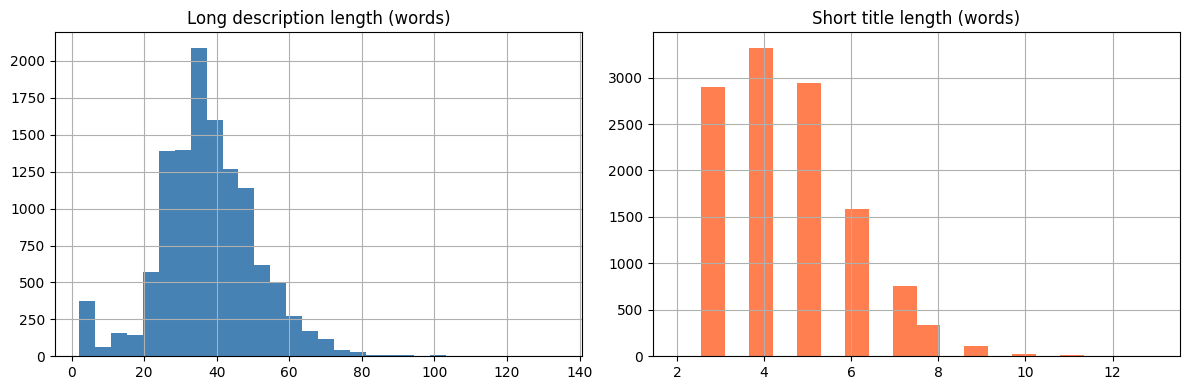

count    12000.000000
mean        37.615167
std         13.850507
min          2.000000
25%         29.000000
50%         37.000000
75%         45.000000
max        134.000000
Name: text_len, dtype: float64


In [8]:
train["text_len"]      = train["text"].str.split().str.len()
train["title_len"]     = train["category3"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train["text_len"].hist(bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Long description length (words)")
train["title_len"].hist(bins=20, ax=axes[1], color="coral")
axes[1].set_title("Short title length (words)")
plt.tight_layout()
plt.show()

print(train["text_len"].describe())

In [9]:
os.listdir(IMG_DIR)

['test', 'train', 'val']

In [10]:
# count images per split
for split in ["train", "val", "test"]:
    split_path = IMG_DIR / split
    if split_path.exists():
        n = len(list(split_path.glob("*.jpg")))
        print(f"{split}: {n} images")

train: 12000 images
val: 1500 images
test: 1197 images


### Check the alignment

In [11]:
def check_split_alignment(df, split):
    split_path = IMG_DIR / split
    if not split_path.exists():
        print(f"{split}: folder not found at {split_path}")
        return

    available = {p.stem for p in split_path.glob("*.jpg")}  # item_IDs on disk
    in_csv = set(df["item_ID"].astype(str))

    missing = in_csv - available
    extra = available - in_csv

    print(f"{split}:")
    print(f"  In CSV but missing on disk : {len(missing)}")
    print(f"  On disk but not in CSV     : {len(extra)}")

for split_name, frame in [("train", train), ("val", val), ("test", test)]:
    check_split_alignment(frame, split_name)

train:
  In CSV but missing on disk : 0
  On disk but not in CSV     : 0
val:
  In CSV but missing on disk : 0
  On disk but not in CSV     : 0
test:
  In CSV but missing on disk : 300
  On disk but not in CSV     : 0


### Visualize Random Samples

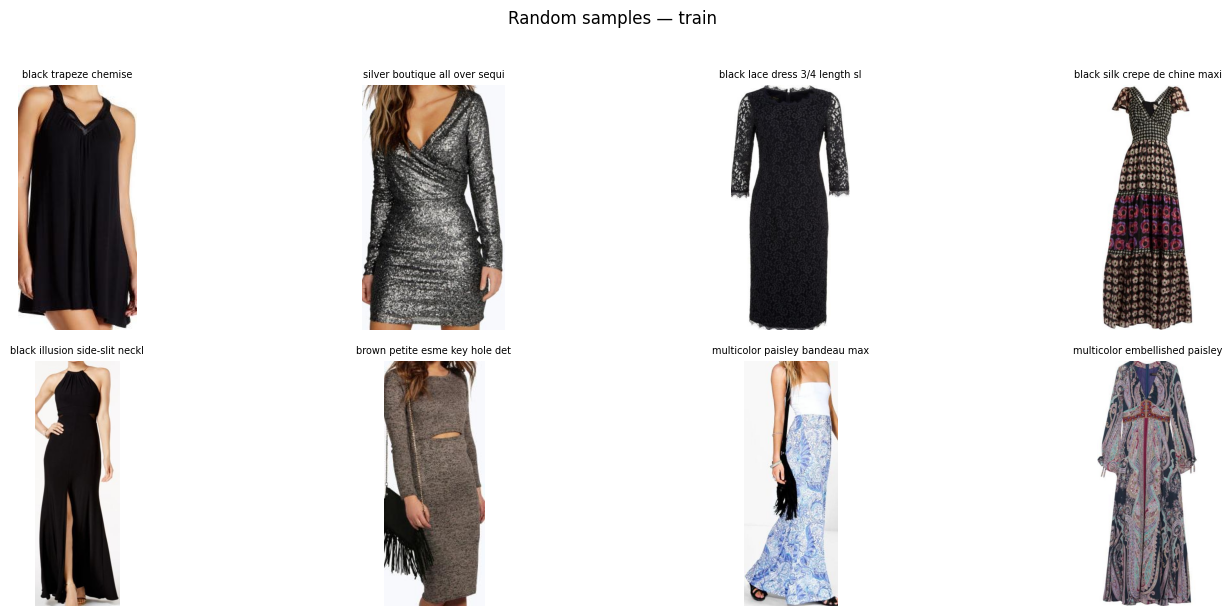

In [15]:
def show_samples(df, split="train", n=8):
    sample = df.sample(n)
    fig, axes = plt.subplots(2, n//2, figsize=(16, 6))
    axes = axes.flatten()
    for i, (_, row) in enumerate(sample.iterrows()):
        img_path = IMG_DIR / split / f"{row['item_ID']}.jpg"
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(row["category3"][:30], fontsize=7)
        axes[i].axis("off")
    plt.suptitle(f"Random samples — {split}", y=1.02)
    plt.tight_layout()
    plt.show()

show_samples(train, "train")

### Visualize by subcategory

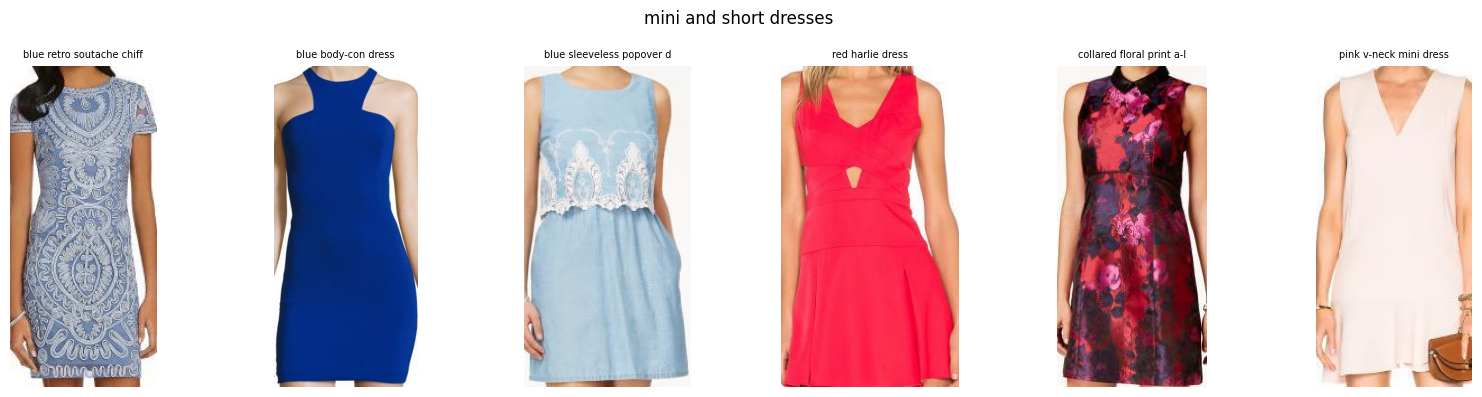

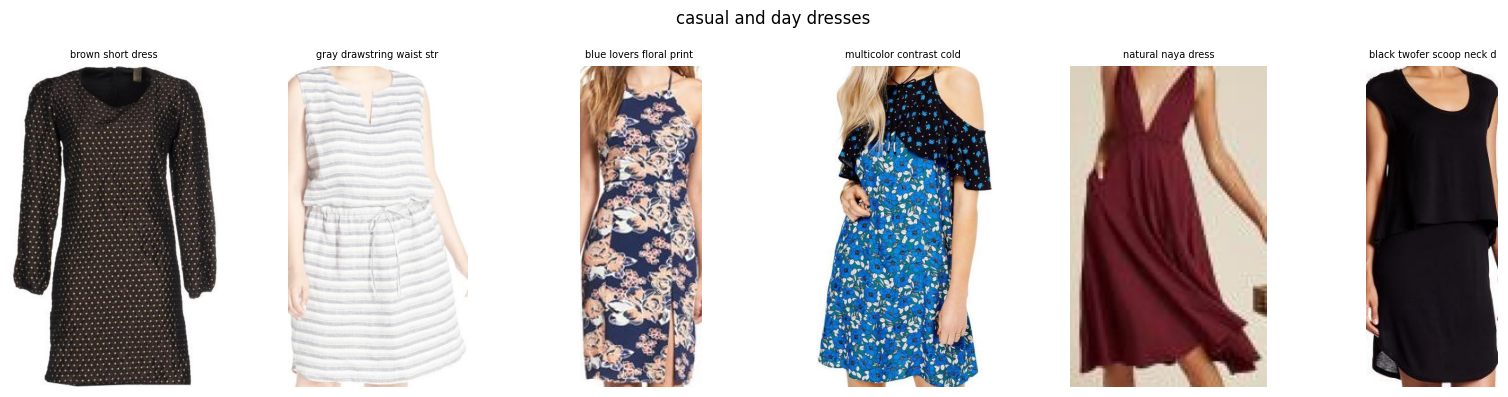

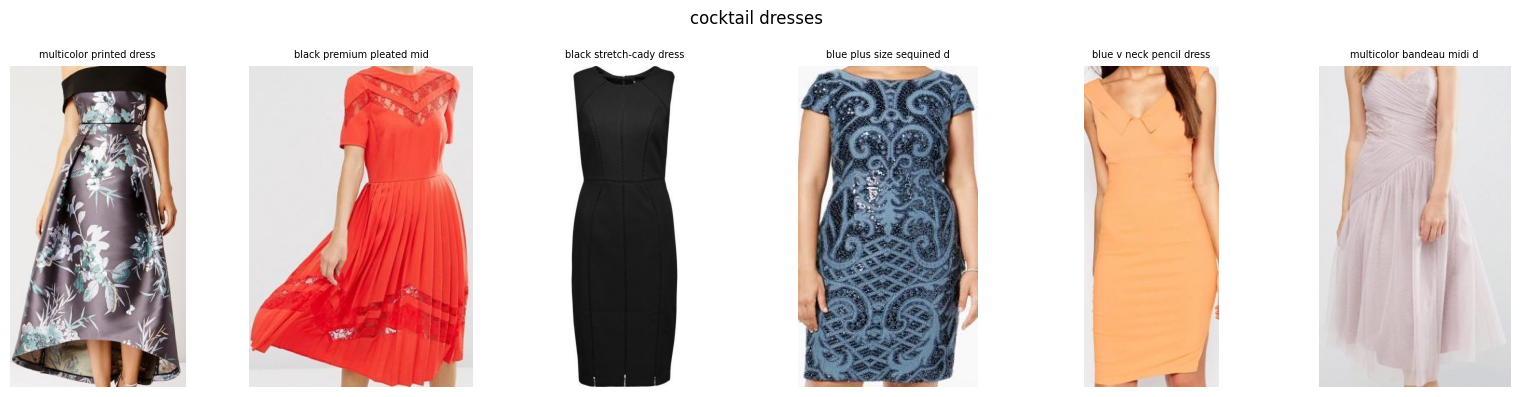

In [16]:
def show_by_category(df, category, split="train", n=6):
    subset = df[df["category2"] == category].sample(n)
    fig, axes = plt.subplots(1, n, figsize=(16, 4))
    for i, (_, row) in enumerate(subset.iterrows()):
        img_path = IMG_DIR / split / f"{row['item_ID']}.jpg"
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(row["category3"][:25], fontsize=7)
        axes[i].axis("off")
    plt.suptitle(category)
    plt.tight_layout()
    plt.show()

# try any category from your barh plot
for cat in train["category2"].value_counts().index[:3]:
    show_by_category(train, cat)

In [17]:
sample = train.sample(5)[["category3", "text"]].reset_index(drop=True)
for _, row in sample.iterrows():
    print(f"TITLE : {row['category3']}")
    print(f"TEXT  : {row['text']}")
    print("-" * 80)

TITLE : red tweed cap-sleeve sheath dress
TEXT  : white dress with short sleeves and a boat neckline. the dress is made of a shiny material and has a fitted silhouette. the dress is a knee-length and is suitable for formal occasions.
--------------------------------------------------------------------------------
TITLE : multicolor cold shoulder cut-out midi dress
TEXT  : silver metallic dress with a halter neckline and a low back. the dress has a draped design and is made of a shiny material.
--------------------------------------------------------------------------------
TITLE : beige dark dress
TEXT  : blue and white dress with a floral print. the dress has a loose fit and features a long sleeve design. the dress is made of a lightweight material and has a flowy silhouette.
--------------------------------------------------------------------------------
TITLE : pink silk tassel maxi dress
TEXT  : multicolored dress with a tie front. the dress has a purple, pink, and blue color schem